# Расследование II-05 · Знакомый почерк

**Бюро аналитических расследований, 14–15 апреля 2026 года.** Антон Карев приносит монтаж из удачных распознаваний рукописных цифр и одну агрегированную долю правильных ответов (accuracy). Вера Орлова просит восстановить процедуру: на каких классах модель ошибается, что именно перебиралось и какая конфигурация будет заморожена до финального экзамена.

**Для кого:** студент после II-04, знакомый с разбиением, базовыми моделями и кросс-валидацией.

**Практическая задача:** прочитать замороженный `digits.csv`, предсказать цифру 0–9 для каждой строки из 64 пикселей и выбрать модель без знакомства с внешней тестовой выборкой. Успех означает, что выбранная по macro-F1 модель превосходит `DummyClassifier`, а финальный отчёт показывает не только общие метрики, но и конкретные слабые классы и пары путаниц.

**Результат:** аудит источника, изображения `(n, 8, 8)`, единая CV-таблица для базовой модели, k-NN и RBF SVM, объявленный `GridSearchCV`, однократная тестовая оценка, recall по классам, матрица и галерея ошибок, `model_lock.json` и `audit_memo.md`.


## Маршрут расследования

1. Прочитать локальный CSV в `DataFrame` и проверить его SHA-256.
2. Связать таблицу 64 пикселей с изображениями `(n, 8, 8)`.
3. Зафиксировать внешнюю стратифицированную тестовую выборку.
4. Сравнить k-NN и RBF SVM только с помощью кросс-валидации обучающей выборки.
5. Выполнить небольшой, заранее объявленный перебор параметров.
6. Один раз оценить модель на тестовой выборке и исследовать ошибки по цифрам.
7. Зафиксировать модель для расследования II-06.

Ориентир времени — 4–5 часов.


In [1]:
from __future__ import annotations

import hashlib
import random
import urllib.request
import zipfile
from pathlib import Path

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
NOTEBOOK_VARIANT = "solution"
CASE_SLUG = "case-05"
ARCHIVE_NAME = "part-2-case-05.zip"
COURSE_SITE = "https://mkuziuk.github.io/python-tutorial"
IN_COLAB = False

# При локальном запуске используем файлы из каталога расследования; в Colab скачиваем архив и проверяем его SHA-256.
# Импорт google.colab проходит только в Colab; локально возникает ImportError, и IN_COLAB остаётся False.
try:
    import google.colab  # type: ignore[import-not-found]  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def find_local_case() -> Path | None:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "README.md").is_file()
            and (candidate / f"{CASE_SLUG}.ipynb").is_file()
        ):
            return candidate
        nested = candidate / "projects" / "part-2" / CASE_SLUG
        if (nested / "README.md").exists():
            return nested
    return None

def download_colab_case() -> Path:
    destination = Path("/content") / f"python-tutorial-{CASE_SLUG}"
    destination.mkdir(parents=True, exist_ok=True)
    archive_path = destination / ARCHIVE_NAME
    archive_url = f"{COURSE_SITE}/downloads/{ARCHIVE_NAME}"
    checksum_url = f"{archive_url}.sha256"

    urllib.request.urlretrieve(archive_url, archive_path)
    # Сравниваем SHA-256 архива с опубликованной контрольной суммой перед распаковкой.
    with urllib.request.urlopen(checksum_url) as response:
        expected = response.read().decode("utf-8").split()[0].lower()
    actual = sha256_file(archive_path)
    if actual != expected:
        raise RuntimeError(f"SHA-256 архива не совпал: {actual} != {expected}")

    unpacked = destination / "unpacked"
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(unpacked)
    matches = sorted(unpacked.rglob(f"{CASE_SLUG}.ipynb"))
    if not matches:
        raise FileNotFoundError(f"В архиве нет {CASE_SLUG}.ipynb")
    return matches[0].parent

# DATA_DIR и ARTIFACTS_DIR строятся от найденного каталога расследования, поэтому текущая папка не влияет на пути.
CASE_DIR = find_local_case()
if CASE_DIR is None and IN_COLAB:
    CASE_DIR = download_colab_case()
if CASE_DIR is None:
    raise FileNotFoundError(
        f"Не найден каталог {CASE_SLUG}. Запустите тетрадь из каталога расследования."
    )

DATA_DIR = CASE_DIR / "data"
ARTIFACTS_DIR = CASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
print(f"Среда: {'Colab' if IN_COLAB else 'local'} | расследование: {CASE_DIR}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


Среда: local | расследование: /private/var/folders/fv/ts0wlkms131g6wghvr6zgnpm0000gn/T/python-tutorial-part2-run-y2wh8jce/case-05
RANDOM_STATE = 42


Начальная ячейка определяет каталог расследования независимо от текущей рабочей папки. Локально она использует вложенные файлы, а в Colab скачивает архив, сверяет SHA-256 и только затем распаковывает его. В результате `DATA_DIR` указывает на неизменяемые входные данные, а `ARTIFACTS_DIR` — на создаваемые результаты.


In [2]:
import json
import warnings
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

def display_figure(fig):
    """Сохранить график в output даже при неинтерактивном backend."""
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


## 1. Источник и полный аудит таблицы

В архив вложен замороженный `data/digits.csv`: каждая строка — одно изображение цифры, 64 пиксельных столбца — признаки, а `digit` — целевая переменная. Сеть не нужна. `SOURCE.md`, `LICENSE.txt` и `dataset_manifest.json` описывают происхождение и SHA-256 файла.

Сначала проверим точную версию файла, форму и типы столбцов, допустимые диапазоны, пропуски, полные дубликаты и распределение цели. Только после этого преобразуем признаки в `X` формы `(n, 64)`, цель в `y` формы `(n,)` и изображения в `(n, 8, 8)`. Такой порядок не позволяет незаметно передать модели испорченную таблицу.


In [3]:
manifest = json.loads((DATA_DIR / "dataset_manifest.json").read_text(encoding="utf-8"))
data_path = DATA_DIR / manifest["filename"]
actual_sha256 = sha256_file(data_path)
assert actual_sha256 == manifest["sha256"], "SHA-256 digits.csv не совпадает с карточкой"

digits_frame = pd.read_csv(data_path)
pixel_columns = list(manifest["feature_names"])
target_column = manifest["target"]

# Эти проверки связывают фактическую таблицу со схемой manifest до построения модели.
assert digits_frame.shape == (manifest["rows"], manifest["columns"])
assert digits_frame.columns.tolist() == [*pixel_columns, target_column]

source_audit = {
    "shape": digits_frame.shape,
    "dtype_counts": digits_frame.dtypes.astype(str).value_counts().to_dict(),
    "pixel_min": int(digits_frame[pixel_columns].min().min()),
    "pixel_max": int(digits_frame[pixel_columns].max().max()),
    "target_min": int(digits_frame[target_column].min()),
    "target_max": int(digits_frame[target_column].max()),
    "missing_cells": int(digits_frame.isna().sum().sum()),
    "duplicate_rows": int(digits_frame.duplicated().sum()),
    "classes": sorted(digits_frame[target_column].unique().tolist()),
}
assert source_audit["pixel_min"] >= manifest["pixel_range"][0]
assert source_audit["pixel_max"] <= manifest["pixel_range"][1]
assert source_audit["target_min"] == 0 and source_audit["target_max"] == 9
assert source_audit["missing_cells"] == 0

X = digits_frame[pixel_columns].to_numpy(dtype=np.float64)
y = digits_frame[target_column].to_numpy(dtype=np.int64)
images = X.reshape(-1, *manifest["image_shape"])
print(f"Файл: {data_path.name} | SHA-256: {actual_sha256[:12]}…")
display(digits_frame.head())
display(pd.Series(source_audit, name="value").to_frame())
print(f"X={X.shape}, images={images.shape}, y={y.shape}")


Файл: digits.csv | SHA-256: 592cc047d0a1…


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,digit
0,0,0,5,13,9,1,0,0,0,0,...,0,0,0,6,13,10,0,0,0,0
1,0,0,0,12,13,5,0,0,0,0,...,0,0,0,0,11,16,10,0,0,1
2,0,0,0,4,15,12,0,0,0,0,...,0,0,0,0,3,11,16,9,0,2
3,0,0,7,15,13,1,0,0,0,8,...,0,0,0,7,13,13,9,0,0,3
4,0,0,0,1,11,0,0,0,0,0,...,0,0,0,0,2,16,4,0,0,4


,value
shape,"(1797, 65)"
dtype_counts,{'int64': 65}
pixel_min,0
pixel_max,16
target_min,0
target_max,9
missing_cells,0
duplicate_rows,0
classes,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]"


X=(1797, 64), images=(1797, 8, 8), y=(1797,)


Аудит подтверждает форму `(1797, 65)`, целочисленные столбцы, пиксели в диапазоне 0–16, цель 0–9, отсутствие пропусков и полных дубликатов, а также десять ожидаемых классов. После преобразования `X` имеет форму `(1797, 64)`, `images` — `(1797, 8, 8)`, `y` — `(1797,)`. Источник прошёл проверки, поэтому теперь можно изучить вид изображений и баланс цели.


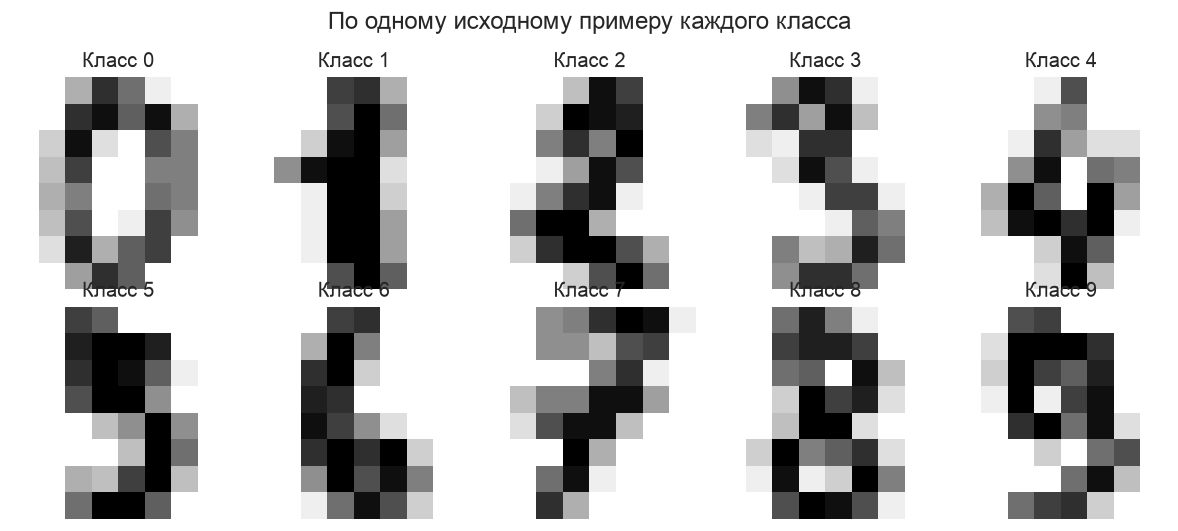

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit, ax in enumerate(axes.ravel()):
    sample_index = int(np.flatnonzero(y == digit)[0])
    ax.imshow(images[sample_index], cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"Класс {digit}")
    ax.axis("off")
fig.suptitle("По одному исходному примеру каждого класса")
plt.tight_layout()
display_figure(fig)


Галерея показывает по первому по индексу примеру каждого класса. Все панели используют общую шкалу 0–16, поэтому яркость сопоставима. Это не случайная и не отобранная вручную демонстрация; для оценки частоты классов нужна отдельная таблица.


In [5]:
class_counts = pd.Series(y, name="digit").value_counts().sort_index()
pixel_summary = pd.Series(X.ravel(), name="pixel_value").describe(
    percentiles=[0.25, 0.5, 0.75]
)
display(pd.DataFrame({"count": class_counts}))
display(pixel_summary.to_frame().round(2))
print("Проверка разворота:", np.array_equal(X[0].reshape(8, 8), images[0]))


,count
digit,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174


,pixel_value
count,115008.00
mean,4.88
std,6.02
min,0.00
25%,0.00
50%,1.00
75%,10.00
max,16.00


Проверка разворота: True


В каждом классе примерно 174–183 строки, поэтому сильного дисбаланса нет. Нулевая медиана пикселей ожидаема: большая часть поля 8×8 остаётся фоном. Проверка разворота подтверждает, что первая строка `X` и первое изображение содержат одни и те же 64 значения в том же порядке. Теперь можно отделить тестовые строки, не используя их для выбора.


## 2. Изолируем внешнюю тестовую выборку

`train_test_split` отделяет 25% строк для единственной финальной проверки. `stratify=y` сохраняет доли десяти классов. Мы создадим `X_test` и `y_test`, но до фиксации модели ни одна метрика, прогноз или таблица не будет их читать.

**Упражнение:** добавьте стратификацию и проверьте, что обучающая и тестовая выборки не пересекаются по индексам.


In [6]:
all_indices = np.arange(len(y))
# BEGIN SOLUTION
# stratify сохраняет доли всех десяти классов в обеих частях разбиения.
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)
# END SOLUTION
X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]
assert set(train_indices).isdisjoint(test_indices)

# Журнал останется пустым до фиксации результата GridSearchCV.
holdout_access_log = []
selection_complete = False
print(f"обучение={len(train_indices)}, изолированный тест={len(test_indices)}")
print("События доступа к тесту:", holdout_access_log)


обучение=1347, изолированный тест=450
События доступа к тесту: []


Получены 1 347 обучающих и 450 тестовых строк без пересечения индексов. Пустой `holdout_access_log` подтверждает, что после отделения тест ещё не оценивался. Для baseline и кандидатов далее используется только `X_train` и `y_train`.


## 3. Общая точка отсчёта и кандидаты

`DummyClassifier(strategy="most_frequent")` всегда выбирает самый частый класс и показывает качество процедуры без полезного сигнала. k-NN классифицирует по близким обучающим примерам, а RBF SVM строит нелинейную границу по сходству. Масштабирование находится внутри `Pipeline`, поэтому `StandardScaler` обучается заново только на обучающих строках каждой части.

Для честного сравнения все три модели получают **один и тот же** объект `StratifiedKFold`. Accuracy — доля всех правильных ответов. Macro-F1 сначала объединяет precision и recall каждого класса в F1, а затем даёт десяти классам одинаковый вес. Поэтому она лучше замечает слабый класс, который общая accuracy может скрыть.


In [7]:
candidates = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "knn_5": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "rbf_svm": make_pipeline(StandardScaler(), SVC(kernel="rbf")),
}
# Одинаковый объект cv задаёт одни и те же индексы частей для всех моделей.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


In [8]:
# BEGIN SOLUTION
cv_rows = []
for model_name, model in candidates.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
        n_jobs=1,
    )
    cv_rows.append({
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
    })
cv_comparison = (
    pd.DataFrame(cv_rows)
    .set_index("model")
    .sort_values("macro_f1_mean", ascending=False)
)
# END SOLUTION
display(cv_comparison.round(4))


,accuracy_mean,macro_f1_mean,macro_f1_std
model,,,
rbf_svm,0.9703,0.9702,0.0011
knn_5,0.9621,0.9621,0.0046
dummy_most_frequent,0.1010,0.0183,0.0002


На одинаковых частях CV базовая модель даёт macro-F1 около `0,018`, k-NN — `0,962`, RBF SVM — `0,970`. Разница между содержательными моделями мала, но SVM лидирует по заранее выбранной метрике. Поэтому сетку параметров применяем только к RBF SVM и по-прежнему не открываем тест.


### 4. Маленький объявленный поиск

CV-таблица нужна для выбора семейства модели, а не для открытия теста. До запуска фиксируем четыре конфигурации RBF SVM: `C ∈ {2, 10}` и `gamma ∈ {scale, 0.001}`. `C` регулирует штраф за ошибки, а `gamma` — ширину области влияния отдельного примера. Метрика выбора — macro-F1, части — те же три стратифицированные части, `n_jobs=1`.


In [9]:
svm_pipeline = make_pipeline(StandardScaler(), SVC(kernel="rbf"))
parameter_grid = {
    "svc__C": [2, 10],
    "svc__gamma": ["scale", 0.001],
}
# BEGIN SOLUTION
# Pipeline заново обучает StandardScaler внутри каждой части кросс-валидации.
grid = GridSearchCV(
    svm_pipeline,
    parameter_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    return_train_score=True,
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
locked_config = {
    "pipeline": "StandardScaler -> SVC",
    "kernel": "rbf",
    "C": grid.best_params_["svc__C"],
    "gamma": grid.best_params_["svc__gamma"],
    "selection_metric": "macro_f1",
    "cv": "StratifiedKFold(n_splits=3, shuffle=True, random_state=42)",
}
grid_table = pd.DataFrame(grid.cv_results_)[[
    "param_svc__C", "param_svc__gamma", "mean_test_score", "std_test_score"
]].sort_values("mean_test_score", ascending=False)
# END SOLUTION
display(grid_table.round(4))
print("Зафиксированная конфигурация:", locked_config)

# Только эта строка завершает выбор: до неё журнал доступа к тесту обязан быть пуст.
assert holdout_access_log == []
selection_complete = True


,param_svc__C,param_svc__gamma,mean_test_score,std_test_score
0,2,scale,0.9739,0.0010
2,10,scale,0.9739,0.0010
3,10,0.001,0.9663,0.0033
1,2,0.001,0.9545,0.0078


Зафиксированная конфигурация: {'pipeline': 'StandardScaler -> SVC', 'kernel': 'rbf', 'C': 2, 'gamma': 'scale', 'selection_metric': 'macro_f1', 'cv': 'StratifiedKFold(n_splits=3, shuffle=True, random_state=42)'}


Лучший средний macro-F1 в объявленной сетке получает `C=2`, `gamma="scale"`. `locked_config` фиксирует и параметры, и правило выбора; пустой журнал непосредственно перед `selection_complete = True` доказывает, что тестовые значения не участвовали в решении. Теперь разрешена одна финальная оценка.


## 5. Открываем тест ровно один раз

Модель и правило выбора уже зафиксированы по обучающей выборке. Функция ниже проверяет `selection_complete`, запрещает повторный вызов и только затем читает `X_test` и `y_test`. Она возвращает прогнозы, accuracy, macro-F1 и recall каждого класса одним пакетом; после этого тестовые результаты используются только для описания ошибок, а не для нового подбора.


In [10]:
def evaluate_locked_model_once(model):
    """Открыть изолированный тест после выбора модели и запретить второй вызов."""
    if not selection_complete:
        raise RuntimeError("Сначала завершите выбор и зафиксируйте конфигурацию модели.")
    if holdout_access_log:
        raise RuntimeError("Внешняя тестовая выборка уже была открыта.")
    holdout_access_log.append("locked_model_final_evaluation")
    predictions = model.predict(X_test)
    return {
        "predictions": predictions,
        "accuracy": accuracy_score(y_test, predictions),
        "macro_f1": f1_score(y_test, predictions, average="macro"),
        "per_class_recall": recall_score(y_test, predictions, average=None),
    }


holdout_result = evaluate_locked_model_once(best_model)
test_predictions = holdout_result["predictions"]
test_accuracy = holdout_result["accuracy"]
test_macro_f1 = holdout_result["macro_f1"]
per_class_recall = pd.Series(
    holdout_result["per_class_recall"],
    index=np.arange(10),
    name="recall",
)
print(f"Тест: accuracy={test_accuracy:.3f}; macro-F1={test_macro_f1:.3f}")
display(per_class_recall.to_frame().round(3))
print("События доступа к тесту:", holdout_access_log)


Тест: accuracy=0.980; macro-F1=0.980


,recall
0,1.000
1,0.978
2,1.000
3,1.000
4,0.978
5,0.978
6,1.000
7,0.978
8,0.930
9,0.956


События доступа к тесту: ['locked_model_final_evaluation']


Единственная тестовая оценка даёт accuracy `0,980` и macro-F1 `0,980`; журнал содержит ровно событие `locked_model_final_evaluation`. Самый низкий recall у цифры 8 — `0,930`, затем у цифры 9 — `0,956`. Общие метрики высоки, но таблица recall указывает, где искать ошибки в матрице.


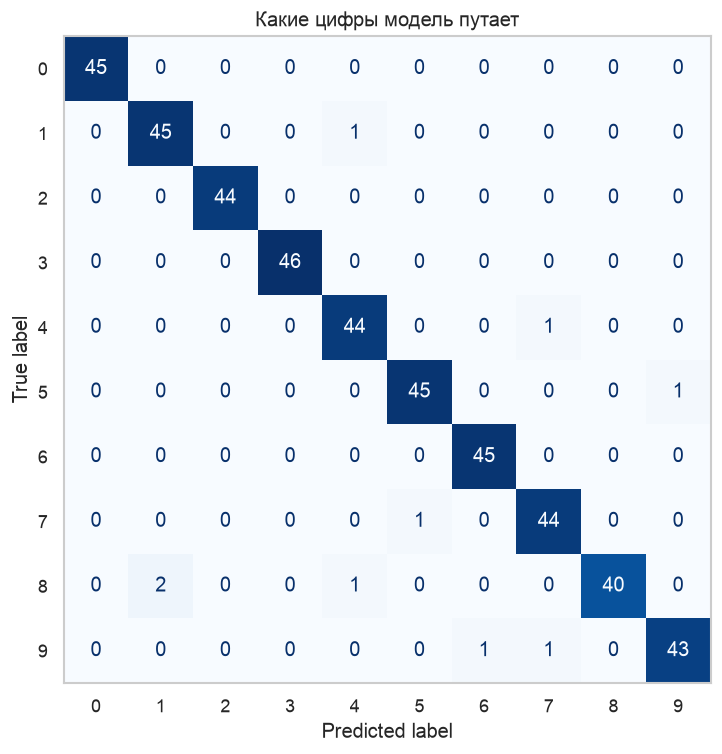

count
Истинный класс Предсказанный класс       
8              1                        2
1              4                        1
4              7                        1
5              9                        1
7              5                        1
8              4                        1
9              6                        1
               7                        1

In [11]:
confusion = pd.crosstab(
    pd.Series(y_test, name="Истинный класс"),
    pd.Series(test_predictions, name="Предсказанный класс"),
).reindex(index=np.arange(10), columns=np.arange(10), fill_value=0)

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(confusion_matrix=confusion.to_numpy(), display_labels=np.arange(10)).plot(
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Какие цифры модель путает")
ax.grid(False)
display_figure(fig)

off_diagonal_values = confusion.to_numpy(copy=True)
np.fill_diagonal(off_diagonal_values, 0)
off_diagonal = pd.DataFrame(
    off_diagonal_values,
    index=confusion.index,
    columns=confusion.columns,
)
confusion_pairs = (
    off_diagonal.stack()
    .rename("count")
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
)
display(confusion_pairs.to_frame().head(10))


Матрица показывает девять ошибок из 450 объектов. Единственная повторившаяся направленная пара — истинная **8**, предсказанная **1**: два случая. Пары `4 → 7`, `5 → 9`, `9 → 7`, `9 → 6`, `7 → 5`, `1 → 4` и `8 → 4` встречаются по одному разу. Это наблюдение описывает данный тест; причины формы штрихов проверим только как гипотезы в галерее.


## 5. Галерея ошибок вместо монтажа успехов

Ошибки сортируем воспроизводимо по индексу тестовой выборки. Галерея не объясняет причину автоматически: она помогает сформулировать проверяемую гипотезу о форме штриха или паре классов.


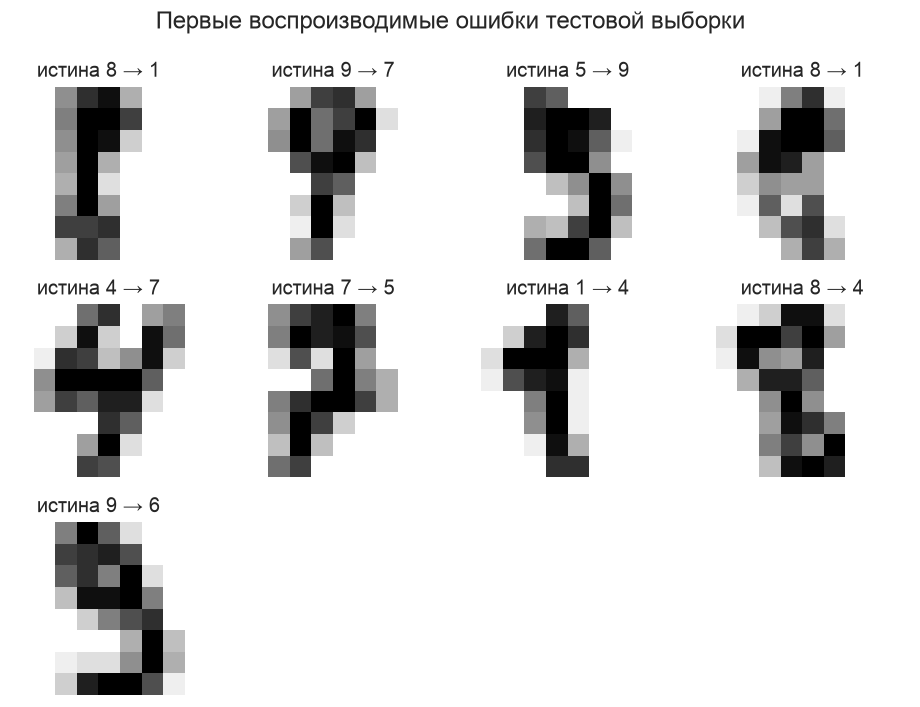

Ошибок в тестовой выборке: 9 из 450


In [12]:
# shown содержит первые 12 ошибок в порядке индексов тестовой выборки.
# flatnonzero() возвращает позиции, где условие ошибки равно True.
error_positions = np.flatnonzero(test_predictions != y_test)
shown = error_positions[: min(12, len(error_positions))]
if len(shown):
    fig, axes = plt.subplots(3, 4, figsize=(8, 6))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, local_position in zip(axes.ravel(), shown, strict=False):
        source_index = test_indices[local_position]
        ax.imshow(images[source_index], cmap="gray_r", vmin=0, vmax=16)
        ax.set_title(f"истина {y_test[local_position]} → {test_predictions[local_position]}")
        ax.axis("off")
    fig.suptitle("Первые воспроизводимые ошибки тестовой выборки")
    plt.tight_layout()
    display_figure(fig)
print(f"Ошибок в тестовой выборке: {len(error_positions)} из {len(y_test)}")


Галерея содержит все девять ошибок в порядке исходных тестовых индексов, а не выбранные вручную примеры. В ней можно визуально сопоставить две ошибки `8 → 1` с единичными случаями, но изображения 8×8 не позволяют доказать, какой именно штрих вызвал решение модели. Для количественного итога используем отчёт по классам.


In [13]:
class_report = pd.DataFrame(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(10),
        output_dict=True,
        zero_division=0,
    )
).T
class_metrics = class_report.loc[
    [str(i) for i in range(10)],
    ["precision", "recall", "f1-score", "support"],
]
display(class_metrics.round(3))


,precision,recall,f1-score,support
0,1.000,1.000,1.000,45.0
1,0.957,0.978,0.968,46.0
2,1.000,1.000,1.000,44.0
3,1.000,1.000,1.000,46.0
4,0.957,0.978,0.967,45.0
5,0.978,0.978,0.978,46.0
6,0.978,1.000,0.989,45.0
7,0.957,0.978,0.967,45.0
8,1.000,0.930,0.964,43.0
9,0.977,0.956,0.966,45.0


Отчёт согласуется с таблицей recall и матрицей: класс 8 имеет наименьшие recall (`0,930`) и F1, тогда как классы 0, 2, 3 и 6 распознаны без пропусков на этом тесте. Эти значения отвечают на вопрос о наблюдаемых слабых классах, но не гарантируют тот же порядок на другом источнике данных.


### 7. Замораживаем модель и вывод

`model_lock.json` фиксирует правило выбора, параметры и единственную тестовую оценку до перехода к II-06. `audit_memo.md` отделяет измеренные результаты от интерпретации и буквально отвечает на вопрос о слабейшем классе и частой паре ошибок. Мы не называем ошибку «почерком конкретного автора»: Digits не содержит идентификатора автора.


In [14]:
# BEGIN SOLUTION
weakest_class = int(per_class_recall.idxmin())
weakest_recall = float(per_class_recall.min())
top_true_class, top_predicted_class = map(int, confusion_pairs.index[0])
top_pair_count = int(confusion_pairs.iloc[0])

lock_payload = {
    **locked_config,
    "random_state": RANDOM_STATE,
    "holdout_access_events": holdout_access_log.copy(),
    "holdout_accuracy": float(test_accuracy),
    "holdout_macro_f1": float(test_macro_f1),
    "weakest_recall_class": weakest_class,
    "weakest_recall": weakest_recall,
    "most_common_confusion": {
        "true_class": top_true_class,
        "predicted_class": top_predicted_class,
        "count": top_pair_count,
    },
}
memo = {
    "established_fact": (
        f"После выбора по обучающей выборке RBF SVM получила на единственном тесте "
        f"accuracy={test_accuracy:.3f} и macro-F1={test_macro_f1:.3f}. "
        f"Самый низкий recall у цифры {weakest_class}: {weakest_recall:.3f}. "
        f"Самая частая направленная ошибка — {top_true_class} → {top_predicted_class}: "
        f"{top_pair_count} случая."
    ),
    "supported_interpretation": (
        "Macro-F1 дополняет accuracy, потому что сначала оценивает каждый класс, "
        "а затем усредняет классы с одинаковым весом."
    ),
    "not_proven": "Ошибки не устанавливают автора, причину штриха или качество на другом сканере.",
    "limitations": "Малые изображения 8×8, один учебный датасет и одна внешняя тестовая выборка.",
    "recommended_action": "Сохранить конфигурацию без нового подбора и проверить её на независимых источниках и партиях сканера.",
}
# END SOLUTION

(ARTIFACTS_DIR / "model_lock.json").write_text(
    json.dumps(lock_payload, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
memo_text = "# Аудиторская записка II-05\n\n" + "\n\n".join(
    f"## {key}\n{value}" for key, value in memo.items()
) + "\n"
(ARTIFACTS_DIR / "audit_memo.md").write_text(memo_text, encoding="utf-8")
print(json.dumps(lock_payload, ensure_ascii=False, indent=2))
print(memo_text)


{
  "pipeline": "StandardScaler -> SVC",
  "kernel": "rbf",
  "C": 2,
  "gamma": "scale",
  "selection_metric": "macro_f1",
  "cv": "StratifiedKFold(n_splits=3, shuffle=True, random_state=42)",
  "random_state": 42,
  "holdout_access_events": [
    "locked_model_final_evaluation"
  ],
  "holdout_accuracy": 0.98,
  "holdout_macro_f1": 0.979922728464422,
  "weakest_recall_class": 8,
  "weakest_recall": 0.9302325581395349,
  "most_common_confusion": {
    "true_class": 8,
    "predicted_class": 1,
    "count": 2
  }
}
# Аудиторская записка II-05

## established_fact
После выбора по обучающей выборке RBF SVM получила на единственном тесте accuracy=0.980 и macro-F1=0.980. Самый низкий recall у цифры 8: 0.930. Самая частая направленная ошибка — 8 → 1: 2 случая.

## supported_interpretation
Macro-F1 дополняет accuracy, потому что сначала оценивает каждый класс, а затем усредняет классы с одинаковым весом.

## not_proven
Ошибки не устанавливают автора, причину штриха или качество на другом ска

Оба файла записывают не только выбранные параметры, но и проверяемый результат: один доступ к тесту, слабейший класс 8 и пару `8 → 1`. Записка отделяет измеренный факт от объяснения, ограничений и следующего действия. Это завершает II-05 без дополнительной настройки по тестовым ошибкам.


In [15]:
if NOTEBOOK_VARIANT == "solution":
    assert set(train_indices).isdisjoint(test_indices)
    assert source_audit["missing_cells"] == 0
    assert source_audit["duplicate_rows"] == 0
    assert source_audit["classes"] == list(range(10))
    assert list(cv_comparison.index) == ["rbf_svm", "knn_5", "dummy_most_frequent"]
    assert grid.best_params_ == {"svc__C": 2, "svc__gamma": "scale"}
    assert holdout_access_log == ["locked_model_final_evaluation"]
    assert test_macro_f1 > 0.95
    assert test_macro_f1 > cv_comparison.loc["dummy_most_frequent", "macro_f1_mean"] + 0.50
    assert weakest_class == 8
    assert (top_true_class, top_predicted_class, top_pair_count) == (8, 1, 2)
    assert len(error_positions) >= 1
    assert set(memo) == {
        "established_fact", "supported_interpretation", "not_proven",
        "limitations", "recommended_action"
    }
    print("Проверки решения II-05 пройдены.")
else:
    print("Учебный вариант: строгие проверки включатся после сверки с решением.")


Проверки решения II-05 пройдены.


## Расследование закрыто

Выполните **Restart Kernel → Run All**. В единой CV-таблице RBF SVM опережает k-NN и базовую модель без обращения к тесту. После фиксации `C=2` и `gamma=scale` единственное открытие теста даёт accuracy `0,980` и macro-F1 `0,980`.

Конкретный ответ на вопрос мемо: самый низкий recall у цифры **8** (`0,930`), а самая частая направленная путаница — **8 → 1** (2 случая). Остальные ошибки единичны, поэтому на этой небольшой тестовой выборке их нельзя называть устойчивой закономерностью. `artifacts/model_lock.json` и `artifacts/audit_memo.md` сохраняют этот вывод и границы его применимости.

**Типичная ошибка:** расширять сетку параметров после просмотра тестовой выборки. Тогда тестовая выборка неявно становится проверочной.

**Расширение:** сравните нормированную матрицу ошибок с абсолютной и объясните, на какой вопрос отвечает каждая.
